## Zadanie 1 (5b)

V tomto zadaní budete pracovať s datasetom Heart Failure Clinical Records, ktorý obsahuje záznamy pacientov so zlyhaním srdca, zozbierané počas obdobia ich sledovania.

Dataset je dostupný online: https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records

Na stránke nájdete aj doplňujúce informácie o premenných, ktoré dataset obsahuje. (Odporúčam prečítať :) )

**Body dostanete za odpovede na zvýraznené otázky**


### Úloha 1 (1b)

Načítajte dataset do premennej `data_hf`.

In [2]:
import pandas as pd

data_hf = pd.read_csv('heart_failure_clinical_records_dataset.csv')
data_hf.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


   **Obsahuje dataset chýbajúce hodnoty (NA) ?**

In [8]:
data_hf.isna().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

**Aký typ majú vybrané premenné v datasete ? (numerické/kategorické)** (Ak by ste si pri niektorých premenných neboli istí, zdôvodnite svoju odpoveď.)

- age
- anaemia 
- high_blood_pressure
- serum_sodium
- death_event

In [11]:
data_hf.dtypes

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

**Obsahuje dataset duplicitné záznamy?**

In [13]:
print(data_hf.duplicated().sum())

0


### Úloha 2 (1b)

Skúmajte premennú pohlavie ('sex'). Premenná je kódovaná hodnotami 0 a 1. ( 0 = žena, 1 = muž)

In [17]:
data_hf['sex']

0      1
1      1
2      1
3      1
4      0
      ..
294    1
295    0
296    0
297    1
298    1
Name: sex, Length: 299, dtype: int64

**Koľko záznamov mužov a žien obsahuje dataset?**

In [15]:
sex_counts = data_hf['sex'].value_counts().sort_index()
sex_counts.index = ['ženy', 'muži']
sex_counts


ženy    105
muži    194
Name: count, dtype: int64

**Koľko mužov a žien je nefajčiarov ? (0 = nefajčiar, 1 = fajčiar)**

In [16]:
non_smokers_by_sex = data_hf[data_hf['smoking'] == 0]['sex'].value_counts().sort_index()
non_smokers_by_sex.index = ['ženy - nefajčiarky', 'muži - nefajčiari']
non_smokers_by_sex

ženy - nefajčiarky    101
muži - nefajčiari     102
Name: count, dtype: int64

### Úloha 3 (1b)

Popíšte premennú vek ('age').

In [18]:
data_hf['age'].describe()

count    299.000000
mean      60.833893
std       11.894809
min       40.000000
25%       51.000000
50%       60.000000
75%       70.000000
max       95.000000
Name: age, dtype: float64

**Aký je minimálny, maximálny a priemerný vek pacientov v datasete?**

In [19]:
age_stats = data_hf['age'].agg(['min', 'max', 'mean'])
age_stats

min     40.000000
max     95.000000
mean    60.833893
Name: age, dtype: float64

**Z akého veku je v datasete najviac záznamov?**

In [20]:
data_hf['age'].mode()

0    60.0
Name: age, dtype: float64

### Úloha 4 (1b)

Pridajte do datasetu novú premennú s názvom `risk`, ktorá bude predstavovať riziko úmrtia pacienta po zlyhaní srdca. Táto premenná bude kategorická a bude obsahovať hodnoty 'Low' a 'High'. 
Premennú vytvorte na základe if-else rozhodovania podľa premenných 'age' a 'serum_creatinine':

- Ak je vek pacienta väčší ako 50 a zároveň level kreatinínu v krvnom sére ('serum_creatinine') je väčší ako 1.2 mg/dL, tak hodnota premennej 'Risk' je 'High'.
- V opačnom prípade je hodnota 'Low'

Hint: môžete použiť metódu `apply` na vytvorenie novej premennej, v ktorej použijete lambda funkciu na definovanie podmienok.

In [39]:
data_hf['risk'] = data_hf.apply(
    lambda row:
    'High' if row['age'] > 50 and row['serum_creatinine'] > 1.2
    else 'Low', axis=1
)

data_hf[['age', 'serum_creatinine', 'risk']].head()

,age,serum_creatinine,risk
0,75.0,1.9,High
1,55.0,1.1,Low
2,65.0,1.3,High
3,50.0,1.9,Low
4,65.0,2.7,High


Vizualizujte vysoké riziko úmrtia pre jednotlivé vekové skupiny histogramom:

Hint: Použite metódu `hist` z knižnice `matplotlib.pyplot` na vizualizáciu distribúcie veku pre pacientov s vysokým rizikom úmrtia.

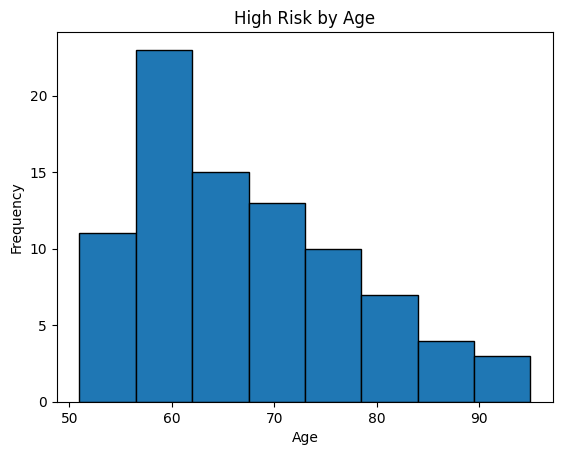

In [41]:
import matplotlib.pyplot as plt

high_risk = data_hf[data_hf['risk'] == 'High']
plt.hist(high_risk['age'], bins='auto', edgecolor='black')
plt.title('High Risk by Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

**V akom veku je riziko zlyhania srdca najväčšie?**

In [27]:
print(high_risk['age'].value_counts().idxmax())

60.0


**Koľko záznamov (približne) je v datasete v tejto vekovej kategórii?**

In [29]:
print(high_risk['age'].value_counts().max())

18


### Úloha 5 (1b)

Analyzujte koreláciu medzi všetkými atribútmi tohto datasetu (napr. vytvorením correlation plot)

Hint: Nenumerické atribúty môžete pred vytvorením korelačnej matice odstrániť.


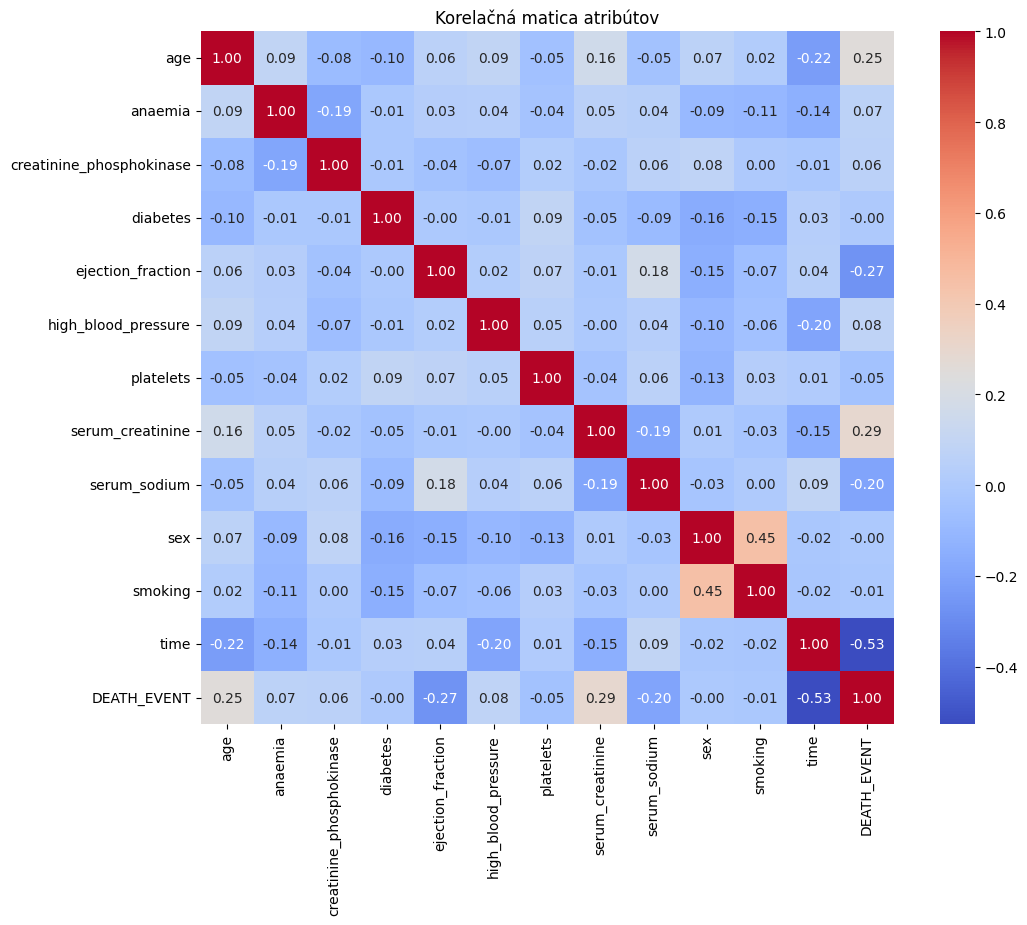

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt


numeric_data = data_hf.select_dtypes(include='number')
corr_matrix = numeric_data.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Korelačná matica atribútov')
plt.show()


**Ktoré atribúty majú medzi sebou najväčšiu zápornú koreláciu?** (uveďte prvé dve dvojice)

In [36]:
pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        pairs.append((cols[i], cols[j], corr_matrix.iloc[i, j]))

pairs = sorted(pairs, key=lambda x: x[2])
pairs[:2]

[('time', 'DEATH_EVENT', np.float64(-0.5269637792775774)),
 ('ejection_fraction', 'DEATH_EVENT', np.float64(-0.26860331239406127))]

**Ktoré atribúty majú medzi sebou najväčšiu kladnú koreláciu?** (uveďte prvú dvojicu)

In [37]:
positive_pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
positive_pairs[:1]

[('sex', 'smoking', np.float64(0.4458917119097906))]

----

Viac informácií o zlyhaní srdca: https://www.nhlbi.nih.gov/health/heart-failure